# Jupyter notebook sample

In [1]:
import matplotlib.pyplot as plt
# Import libraries
import pandas as pd

### Interactive tables

Effortlessly view, navigate, sort, and filter data. Create charts and access essential data insights, including descriptive statistics and missing values – all without writing a single line of code.

In [2]:
# Defining data for the dataframe
data = {
    'Basket': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P'],
    'Apples': [10, 20, 30, 56, 40, 40, 67, 47, 40, 4, 49, 52, 5, 56, 35, 45],
    'Bananas': [15, 6, 3, 45, 67, 44, 45, 11, 14, 18, 13, 12, 1, 34, 12, 12]
}

# Creating the dataframe
df = pd.DataFrame(data)

df

,Basket,Apples,Bananas
0,A,10,15
1,B,20,6
2,C,30,3
3,D,56,45
4,E,40,67
5,F,40,44
6,G,67,45
7,H,47,11
8,I,40,14
9,J,4,18


### Visualization in IDE

Create graphs and visualizations that match your chosen color scheme.

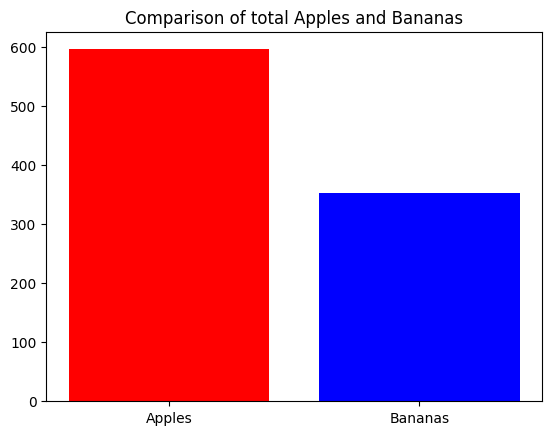

In [3]:
# Calculate the sums
sum_apples = df['Apples'].sum()
sum_bananas = df['Bananas'].sum()

# Create a bar chart
plt.bar(['Apples', 'Bananas'], [sum_apples, sum_bananas], color=['red', 'blue'])

# Set a title
plt.title('Comparison of total Apples and Bananas')

# Show the plot
plt.show()

In [166]:
df = pd.read_excel('operations.xls')
# !pip install xlrd

In [167]:
df.info()# Load data into dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Дата операции                 880 non-null    object 
 1   Дата платежа                  880 non-null    object 
 2   Номер карты                   616 non-null    object 
 3   Статус                        880 non-null    object 
 4   Сумма операции                880 non-null    float64
 5   Валюта операции               880 non-null    object 
 6   Сумма платежа                 880 non-null    float64
 7   Валюта платежа                880 non-null    object 
 8   Кэшбэк                        1 non-null      float64
 9   Категория                     873 non-null    object 
 10  MCC                           630 non-null    float64
 11  Описание                      880 non-null    object 
 12  Бонусы (включая кэшбэк)       880 non-null    int64  
 13  Округ

In [168]:
df['is_expense'] = df['Сумма операции'] < 0

In [169]:
expenses = df[df['is_expense']]

In [170]:
df.rename(columns={'Дата операции': 'date', 'Сумма операции': 'amount', 'описание': 'description', 'Дата платежа' : 'payment_date', 'Статус' : 'status', 'Валюта операции' : 'currency', 'Сумма платежа' : 'sum', 'Категория' : 'category', 'Описание' : 'description'}, inplace=True)

In [171]:
df.drop('payment_date', axis=1, inplace=True)
df.drop('Валюта платежа', axis=1, inplace=True)
df.drop('currency', axis=1, inplace=True)
df.drop('Номер карты', axis=1, inplace=True)
df.drop('Кэшбэк', axis=1, inplace=True)
df.drop('Округление на инвесткопилку', axis=1, inplace=True)
df.drop('Бонусы (включая кэшбэк)', axis=1, inplace=True)
df.drop('Сумма операции с округлением', axis=1, inplace=True)
df.drop('MCC', axis=1, inplace=True)
# df.drop('Date', axis=1, inplace=True)
df.drop('sum', axis=1, inplace=True)

In [172]:
df=df[df['status'] == 'OK']
df.drop('status', axis=1, inplace=True)

In [173]:
# Convert 'date' column to datetime if it's not already
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# Set 'date' as the index
# df.set_index('date', inplace=True)

In [174]:
unique_categories = df['category'].unique()

In [175]:
#!pip install deep_translator

In [176]:
from deep_translator import GoogleTranslator
gt = GoogleTranslator(source='ru', target='en')
for category in unique_categories:
    print(gt.translate(category))

Supermarkets
Translations
Taxi
Mobile communications
Clothes and footwear
Cosmetics
Pharmacies
Marketplaces
Home and renovation
Restaurants
Fast food
Medicine
Air tickets
Books
Stationery
Bonuses
Beauty
Connection
Bank services
Various goods
Digital goods
Yandex Ecosystem
Flowers
Replenishments
Other
Electronics and technology
Private services
Entertainment
Sporting goods
Travel agencies
Cash
Local transport
Auto services
Service
Souvenirs


In [177]:
# df['category'] = df['category'].map(lambda x: gt.translate(x))

In [178]:
#df['category'] = df['category'].map(gt.translate)

In [179]:
#!pip install seaborn

In [180]:
# !pip install --upgrade matplotlib
# !pip install --upgrade seaborn

In [181]:
from deep_translator import GoogleTranslator
def translate_categories(df, category_column='category'):
    # Create translator instance
    translator = GoogleTranslator(source='ru', target='en')

    # Create a dictionary of unique translations to minimize API calls
    unique_categories = df[category_column].unique()
    translation_dict = {
        category: translator.translate(category)
        for category in unique_categories if isinstance(category, str)
    }

    # Replace categories with translations
    df[category_column] = df[category_column].map(translation_dict).fillna(df[category_column])

    return df

In [187]:
def analyze_spending_patterns(df):
    # Monthly spending by category
    monthly_cat = df.groupby([df['date'].dt.strftime('%Y-%m'), 'category'])['amount'].sum().unstack()

    # Identify irregular large expenses
    def find_outliers(group):
        mean = group['amount'].mean()
        std = group['amount'].std()
        return group[abs(group['amount'] - mean) > 2*std]

    outliers = df.groupby('category').apply(find_outliers)

    # Late night spending (potential impulse purchases)
    if 'time' in df.columns:
        late_night = df[df['time'].dt.hour >= 23]

    # Day of week analysis
    weekday_spending = df.groupby(df['date'].dt.dayofweek)['amount'].mean()

    return monthly_cat, outliers, weekday_spending

In [188]:
def generate_insights(df):
    # Calculate recurring vs one-time expenses
    recurring = df.groupby(['category', df['date'].dt.strftime('%Y-%m')])['amount'].count()
    recurring = recurring.groupby(level=0).mean()

    # Spending volatility by category
    volatility = df.groupby('category')['amount'].std()

    return recurring, volatility

In [196]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

class FinancialAdvisor:
    def __init__(self, df):
        self.df = df
        self.df['date'] = pd.to_datetime(self.df['date'])

    def analyze_spending_patterns(self):
        patterns = {
            'monthly_by_category': self._get_monthly_category_spending(),
            'unusual_expenses': self._find_unusual_expenses(),
            'spending_trends': self._analyze_spending_trends(),
            'recurring_expenses': self._identify_recurring_expenses(),
            'weekend_spending': self._analyze_weekend_spending()
        }
        return patterns

    def _get_monthly_category_spending(self):
        return self.df.groupby([pd.Grouper(key='date', freq='ME'), 'category'])['amount'].sum()

    def _find_unusual_expenses(self):
        def get_outliers(group):
            mean = group['amount'].mean()
            std = group['amount'].std()
            return group[abs(group['amount'] - mean) > 2 * std]

        return self.df.groupby('category').apply(get_outliers)

    def _analyze_spending_trends(self):
        daily_spending = self.df.groupby('date')['amount'].sum()
        return daily_spending.rolling(window=7).mean()

    def _identify_recurring_expenses(self):
        monthly_transactions = self.df.groupby(['category', pd.Grouper(key='date', freq='ME')])['amount'].count()
        return monthly_transactions[monthly_transactions >= 2]

    def _analyze_weekend_spending(self):
        self.df['is_weekend'] = self.df['date'].dt.dayofweek >= 5
        return self.df.groupby('is_weekend')['amount'].agg(['mean', 'sum'])

    def visualize_spending(self):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Monthly spending trend
        monthly_total = self.df.groupby(pd.Grouper(key='date', freq='ME'))['amount'].sum()
        axes[0, 0].plot(monthly_total.index, monthly_total.values)
        axes[0, 0].set_title('Monthly Spending Trend')
        axes[0, 0].tick_params(axis='x', rotation=45)

        # Category distribution
        category_totals = self.df.groupby('category')['amount'].sum()
        axes[0, 1].pie(category_totals.values, labels=category_totals.index, autopct='%1.1f%%')
        axes[0, 1].set_title('Spending by Category')

        # Daily spending pattern
        daily_spending = self.df.groupby('date')['amount'].sum()
        axes[1, 0].plot(daily_spending.index, daily_spending.values)
        axes[1, 0].set_title('Daily Spending Pattern')
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Category-wise bar plot
        category_avg = self.df.groupby('category')['amount'].mean()
        axes[1, 1].bar(category_avg.index, category_avg.values)
        axes[1, 1].set_title('Average Spending by Category')
        axes[1, 1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        return fig

    def generate_advice(self):
        advice = []
        patterns = self.analyze_spending_patterns()

        # Analyze monthly trends
        monthly_spending = patterns['monthly_by_category']
        recent_months = monthly_spending.last('3M')

        # Check for increasing trends
        for category in recent_months.index.get_level_values(1).unique():
            category_data = recent_months.xs(category, level=1)
            if len(category_data) >= 3 and category_data.is_monotonic_increasing:
                advice.append(f"WARNING: Your spending in {category} has been steadily increasing. "
                              f"Consider setting a budget for this category.")

        # Analyze unusual expenses
        unusual = patterns['unusual_expenses']
        if not unusual.empty:
            recent_unusual = unusual[unusual.date >= (datetime.now() - timedelta(days=30))]
            if not recent_unusual.empty:
                advice.append("Recent unusual expenses detected in categories: " +
                              ", ".join(recent_unusual['category'].unique()))

        # Weekend spending analysis
        weekend_stats = patterns['weekend_spending']
        if weekend_stats.loc[True, 'mean'] > weekend_stats.loc[False, 'mean'] * 1.5:
            advice.append("Your weekend spending is significantly higher than weekday spending. "
                          "Consider planning weekend activities in advance to control costs.")

        return advice

# Usage example:
# """
# # Initialize advisor
# advisor = FinancialAdvisor(df)
#
# # Get financial advice
# advice = advisor.generate_advice()
# for tip in advice:
#     print(tip)
#
# # Visualize spending
# advisor.visualize_spending()
# plt.show()
# """

In [197]:
# Initialize advisor
advisor = FinancialAdvisor(df)

In [198]:
# Get financial advice
advice = advisor.generate_advice()
for tip in advice:
    print(tip)

/var/folders/dg/3075cgkj2p12184z1r0949pm0000gn/T/ipykernel_70057/3459127806.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return self.df.groupby('category').apply(get_outliers)
/var/folders/dg/3075cgkj2p12184z1r0949pm0000gn/T/ipykernel_70057/3459127806.py:78: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent_months = monthly_spending.last('3M')


TypeError: 'last' only supports a DatetimeIndex index

In [204]:
def get_monthly_category_spending(df):
    # Ensure date is in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Method 1: Pivot table format (categories as columns)
    monthly_pivot = df.pivot_table(
        index=pd.Grouper(key='date', freq='ME'),
        columns='category',
        values='amount',
        aggfunc='sum'
    ).round(2)

    # Method 2: Stacked format (long format)
    monthly_stacked = df.groupby([
        pd.Grouper(key='date', freq='ME'),
        'category'
    ])['amount'].sum().round(2)

    # Method 3: Unstacked format (similar to pivot)
    monthly_unstacked = monthly_stacked.unstack(fill_value=0).round(2)

    # Method 4: As DataFrame with month and category as columns
    monthly_df = df.groupby([
        pd.Grouper(key='date', freq='ME'),
        'category'
    ])['amount'].sum().reset_index()

    return {
        'pivot': monthly_pivot,
        'stacked': monthly_stacked,
        'unstacked': monthly_unstacked,
        'dataframe': monthly_df
    }

In [205]:
results = get_monthly_category_spending(df)

In [207]:
results['pivot']

category,Авиабилеты,Автоуслуги,Аптеки,Бонусы,Дом и ремонт,Другое,Канцтовары,Книги,Косметика,Красота,...,Супермаркеты,Такси,Турагентства,Услуги банка,Фастфуд,Цветы,Цифровые товары,Частные услуги,Экосистема Яндекс,Электроника и техника
date,,,,,,,,,,,,,,,,,,,,,
2024-09-30,NaN,NaN,-1188.50,540.83,NaN,-2489.0,NaN,-3692.0,NaN,-14319.83,...,-23990.37,-12497.0,-62253.0,-5582.54,-10140.0,-19600.0,-1000.0,NaN,-2217.93,NaN
2024-10-31,NaN,-300.0,-19168.91,1711.91,-2858.0,-2489.0,NaN,-7092.0,NaN,-11040.06,...,-42148.12,-40655.0,-139442.0,-1614.75,-11201.5,-9534.0,-1000.0,-10000.00,-649.00,NaN
2024-11-30,-141675.0,NaN,-9512.76,2226.98,-6404.0,-2489.0,NaN,NaN,NaN,-19553.15,...,-40360.87,-13434.0,NaN,-390.00,-6391.0,-15000.0,-1954.0,-528.15,-1547.25,-2599.0
2024-12-31,-70359.0,NaN,-8035.40,1192.72,-486.0,-2489.0,-439.7,-16.0,-4399.3,-4972.56,...,-46815.65,-14462.0,NaN,-8795.98,-8249.0,-21606.0,-1000.0,NaN,-1048.00,NaN


In [208]:
results['stacked']

date        category         
2024-09-30  Аптеки               -1188.50
            Бонусы                 540.83
            Другое               -2489.00
            Книги                -3692.00
            Красота             -14319.83
                                   ...   
2024-12-31  Услуги банка         -8795.98
            Фастфуд              -8249.00
            Цветы               -21606.00
            Цифровые товары      -1000.00
            Экосистема Яндекс    -1048.00
Name: amount, Length: 97, dtype: float64

In [209]:
results['unstacked']

category,Авиабилеты,Автоуслуги,Аптеки,Бонусы,Дом и ремонт,Другое,Канцтовары,Книги,Косметика,Красота,...,Супермаркеты,Такси,Турагентства,Услуги банка,Фастфуд,Цветы,Цифровые товары,Частные услуги,Экосистема Яндекс,Электроника и техника
date,,,,,,,,,,,,,,,,,,,,,
2024-09-30,0.0,0.0,-1188.50,540.83,0.0,-2489.0,0.0,-3692.0,0.0,-14319.83,...,-23990.37,-12497.0,-62253.0,-5582.54,-10140.0,-19600.0,-1000.0,0.00,-2217.93,0.0
2024-10-31,0.0,-300.0,-19168.91,1711.91,-2858.0,-2489.0,0.0,-7092.0,0.0,-11040.06,...,-42148.12,-40655.0,-139442.0,-1614.75,-11201.5,-9534.0,-1000.0,-10000.00,-649.00,0.0
2024-11-30,-141675.0,0.0,-9512.76,2226.98,-6404.0,-2489.0,0.0,0.0,0.0,-19553.15,...,-40360.87,-13434.0,0.0,-390.00,-6391.0,-15000.0,-1954.0,-528.15,-1547.25,-2599.0
2024-12-31,-70359.0,0.0,-8035.40,1192.72,-486.0,-2489.0,-439.7,-16.0,-4399.3,-4972.56,...,-46815.65,-14462.0,0.0,-8795.98,-8249.0,-21606.0,-1000.0,0.00,-1048.00,0.0


In [ ]:
results['dataframe']

In [211]:
def format_monthly_report(df):
    # Get monthly spending
    monthly = get_monthly_category_spending(df)['unstacked']

    # Add total row and column
    monthly['Total'] = monthly.sum(axis=1)
    monthly.loc['Average'] = monthly.mean()

    # Format numbers to currency
    formatted = monthly.applymap(lambda x: f"${x:,.2f}")

    return formatted

In [213]:
def analyze_weekday_spending(df):
    # Ensure date is in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Get day of week
    df['weekday'] = df['date'].dt.day_name()

    # Average spending by day of week
    weekday_avg = df.groupby('weekday')['amount'].mean()

    # Median spending by day of week
    weekday_median = df.groupby('weekday')['amount'].median()

    return weekday_avg, weekday_median

In [214]:
analyze_weekday_spending(df)

(weekday
 Friday      -1490.698881
 Monday      -1619.224495
 Saturday     -316.342837
 Sunday       -947.769833
 Thursday    -1409.785556
 Tuesday      5334.187500
 Wednesday   -1096.374074
 Name: amount, dtype: float64,
 weekday
 Friday      -447.00
 Monday      -557.00
 Saturday    -531.00
 Sunday      -443.35
 Thursday    -536.00
 Tuesday     -403.00
 Wednesday   -860.00
 Name: amount, dtype: float64)

In [215]:
def analyze_spending_trends(df):
    # Ensure date is in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Daily spending
    daily_spending = df.groupby('date')['amount'].sum()

    # 7-day rolling average
    rolling_avg = daily_spending.rolling(window=7).mean()

    return daily_spending, rolling_avg

In [216]:
analyze_spending_trends(df)

(date
 2024-09-01 13:10:43     -1990.00
 2024-09-05 16:08:12      1200.00
 2024-09-05 21:26:06     -1200.00
 2024-09-07 12:23:02      -499.00
 2024-09-07 18:05:04    274050.00
                          ...    
 2024-12-31 11:09:39      -219.96
 2024-12-31 12:59:51      1500.00
 2024-12-31 13:25:35     -1500.00
 2024-12-31 13:25:36      1500.00
 2024-12-31 13:28:30     -1659.94
 Name: amount, Length: 859, dtype: float64,
 date
 2024-09-01 13:10:43           NaN
 2024-09-05 16:08:12           NaN
 2024-09-05 21:26:06           NaN
 2024-09-07 12:23:02           NaN
 2024-09-07 18:05:04           NaN
                           ...    
 2024-12-31 11:09:39   -683.038571
 2024-12-31 12:59:51    270.720000
 2024-12-31 13:25:35   -157.851429
 2024-12-31 13:25:36     70.720000
 2024-12-31 13:28:30     33.585714
 Name: amount, Length: 859, dtype: float64)

In [217]:
def identify_recurring_expenses(df):
    # Ensure date is in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Monthly transactions by category
    monthly_transactions = df.groupby([
        'category',
        pd.Grouper(key='date', freq='M')
    ]).size()

    # Identify recurring expenses
    recurring = monthly_transactions[monthly_transactions >= 2]

    return recurring

In [218]:
identify_recurring_expenses(df)

/var/folders/dg/3075cgkj2p12184z1r0949pm0000gn/T/ipykernel_70057/1099054864.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='date', freq='M')


category           date      
Авиабилеты         2024-11-30     2
Аптеки             2024-09-30     2
                   2024-10-31    12
                   2024-11-30     7
                   2024-12-31     6
                                 ..
Цветы              2024-12-31     2
Цифровые товары    2024-11-30     3
Экосистема Яндекс  2024-09-30     3
                   2024-11-30     3
                   2024-12-31     2
Length: 69, dtype: int64

In [219]:
def find_unusual_expenses(df):
    # Ensure date is in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Define a function to find outliers
    def find_outliers(group):
        mean = group['amount'].mean()
        std = group['amount'].std()
        return group[(group['amount'] - mean).abs() > 2 * std]

    # Apply the function to each category
    unusual = df.groupby('category').apply(find_outliers)

    return unusual

In [220]:
find_unusual_expenses(df)

/var/folders/dg/3075cgkj2p12184z1r0949pm0000gn/T/ipykernel_70057/530319339.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unusual = df.groupby('category').apply(find_outliers)


date     amount           category  \
category                                                                  
Аптеки            470 2024-10-21 16:49:52   -6254.50             Аптеки   
Бонусы            267 2024-11-17 22:55:33    1996.00             Бонусы   
Дом и ремонт      320 2024-11-07 17:24:09   -2999.00       Дом и ремонт   
Красота           351 2024-11-04 13:36:27  -11635.00            Красота   
Маркетплейсы      518 2024-10-18 18:20:03   -5892.00       Маркетплейсы   
Одежда и обувь    829 2024-09-14 14:06:53   -5898.00     Одежда и обувь   
Переводы          396 2024-10-29 18:04:53 -198000.00           Переводы   
                  397 2024-10-29 18:04:53  198000.00           Переводы   
                  402 2024-10-29 17:59:43  256705.00           Переводы   
                  564 2024-10-15 19:59:15  192100.01           Переводы   
                  782 2024-09-24 05:18:50 -297006.68           Переводы   
                  783 2024-09-24 05:18:50  297006.68           Переводы   
                  867 2024-09-07 19:11:32 -197000.00           Переводы   
                  871 2024-09-07 18:10:46  264000.00           Переводы   
                  872 2024-09-07 18:10:45 -264000.00           Переводы   
                  875 2024-09-07 18:05:04  274050.00           Переводы   
Различные товары  153 2024-12-10 21:25:17   -4275.00   Различные товары   
Рестораны         355 2024-11-03 18:53:35   -5025.00          Рестораны   
                  669 2024-10-07 18:59:25   -5343.75          Рестораны   
                  792 2024-09-22 13:41:54   -4680.00          Рестораны   
Супермаркеты      10  2024-12-29 18:57:40   -5176.31       Супермаркеты   
                  130 2024-12-14 16:39:33   -9161.68       Супермаркеты   
                  219 2024-11-27 18:11:59   -4101.35       Супермаркеты   
                  309 2024-11-09 15:53:02   -3981.90       Супермаркеты   
                  462 2024-10-21 20:32:32   -4459.02       Супермаркеты   
                  664 2024-10-07 20:27:42   -3413.76       Супермаркеты   
                  827 2024-09-14 15:44:11   -6889.15       Супермаркеты   
Такси             74  2024-12-21 14:56:06      30.00              Такси   
                  283 2024-11-11 19:22:41    -860.00              Такси   
                  428 2024-10-27 08:16:53    -930.00              Такси   
                  572 2024-10-15 14:08:35   -2000.00              Такси   
                  601 2024-10-13 08:04:10    -934.00              Такси   
                  632 2024-10-10 19:58:15    -844.00              Такси   
                  703 2024-10-04 15:45:52    -990.00              Такси   
                  820 2024-09-17 20:58:13    -840.00              Такси   
Услуги банка      106 2024-12-17 22:39:07   -8795.98       Услуги банка   
Фастфуд           171 2024-12-07 18:12:15   -2349.00            Фастфуд   
                  257 2024-11-23 15:47:59   -2538.00            Фастфуд   
                  434 2024-10-26 10:42:34   -2963.50            Фастфуд   
                  752 2024-09-27 19:27:00   -1950.00            Фастфуд   
                  823 2024-09-15 13:14:23   -2536.00            Фастфуд   
Экосистема Яндекс 379 2024-11-01 12:36:07     -90.00  Экосистема Яндекс   

                                     description  is_expense  is_weekend  \
category                                                                   
Аптеки            470                     Живика        True       False   
Бонусы            267  Кэшбэк за обычные покупки       False        True   
Дом и ремонт      320                        DNS        True       False   
Красота           351           YM*eco-element10        True       False   
Маркетплейсы      518                    Ozon.ru        True       False   
Одежда и обувь    829                       MAAG        True        True   
Переводы          396      Перевод между счетами        True       False   
                  397      Перевод между счетами    